In [57]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [58]:
df = pd.read_csv('chocolate_bar_ratings_2022.csv')

Create a chart that shows a distribution (e.g., histogram, boxplot). 
-Question(s) you're exploring: How many chocolate bars received each rating? Is the data skewed in a particular direction?
-I chose this chart because a histogram (or boxplot) helps you visualize the spread, skew and shape of the data.
-What does the chart help you notice? I noticed that the data is skewed toward the higher end of the rating scale. More bars are rated between 3.0 and 3.5 than any other value. In a normal distribution, most of the data would be clustered around the mean of 2.5 on a 1-4 rating scale. In this case, the mean, as seen in the data exploration, is 3.1.  

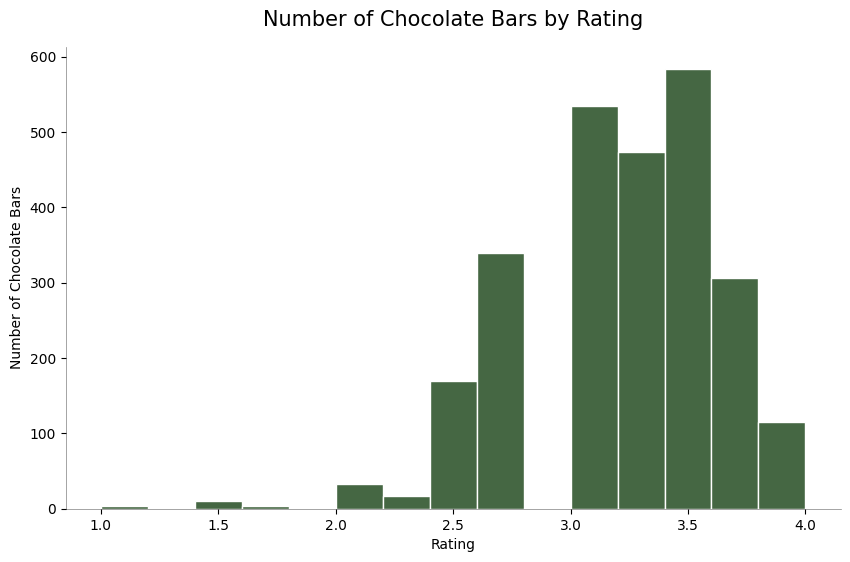

In [104]:
plt.figure(figsize=(10, 6))
plt.hist(
    df['Rating'],
    bins=15, 
    color='#456743',
    edgecolor='white'
)
#need to change the increments to include .25 and .75

plt.xlabel('Rating')
plt.ylabel('Number of Chocolate Bars')
plt.title('Number of Chocolate Bars by Rating', fontsize=15, pad=15)

ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(0.5)
    spine.set_alpha(0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()

I also wanted to see the distribution of beans grown in different countries. This does not tell us anything other than how many bars come from beans grown in each country. Perhaps these can be grouped by region later on.

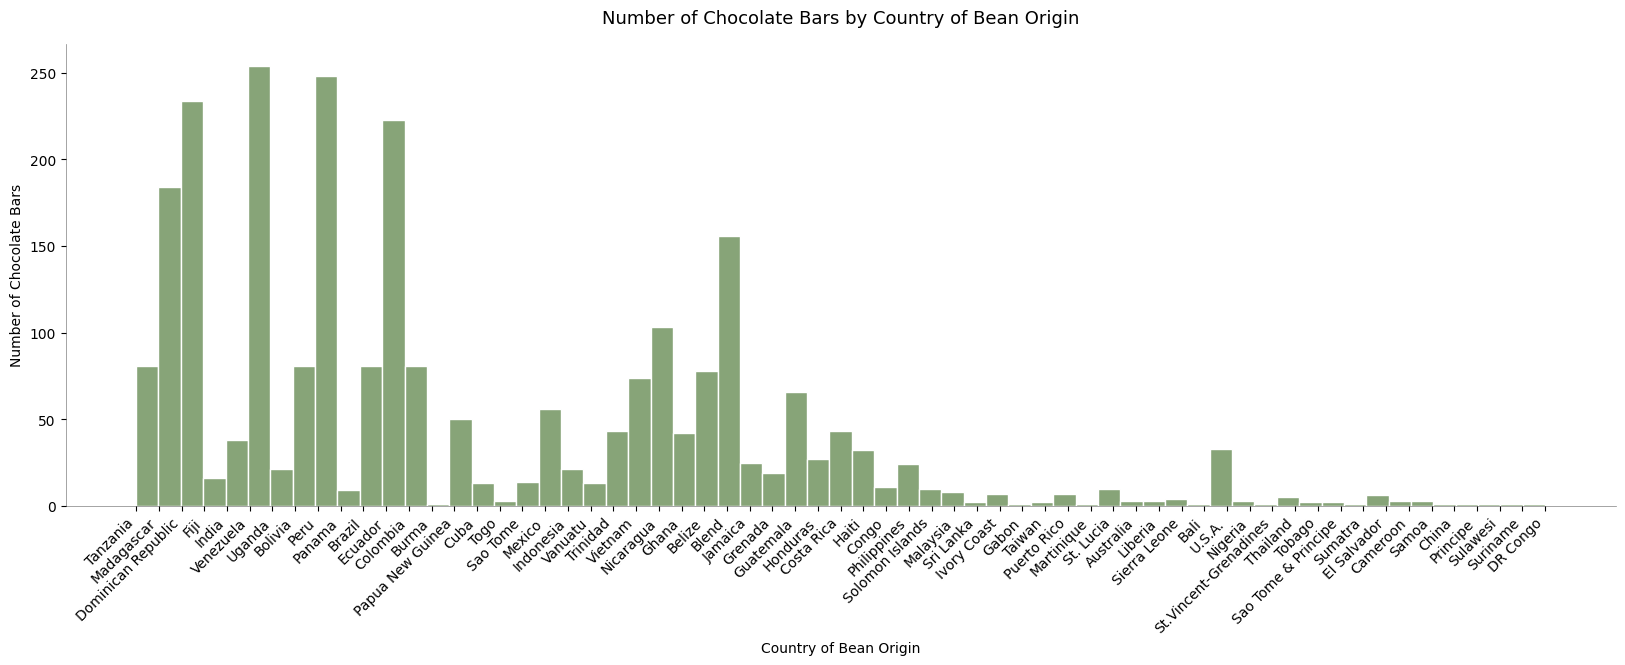

In [108]:
plt.figure(figsize=(20, 6))
plt.hist(
    df['Country of Bean Origin'],
    bins=63, 
    color='#87A478',
    edgecolor='white'
)
#need to change the increments to include .25 and .75

plt.xlabel('Country of Bean Origin')
plt.ylabel('Number of Chocolate Bars')
plt.title('Number of Chocolate Bars by Country of Bean Origin', fontsize=13, pad=15)
plt.xticks(rotation=45, ha='right')


ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(0.5)
    spine.set_alpha(0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()

Here is the distribution of chocolate bars produced in different countries.  Again, this does not tell us anything other than how many of the chocolate bars used in the dataset were produced in each country.

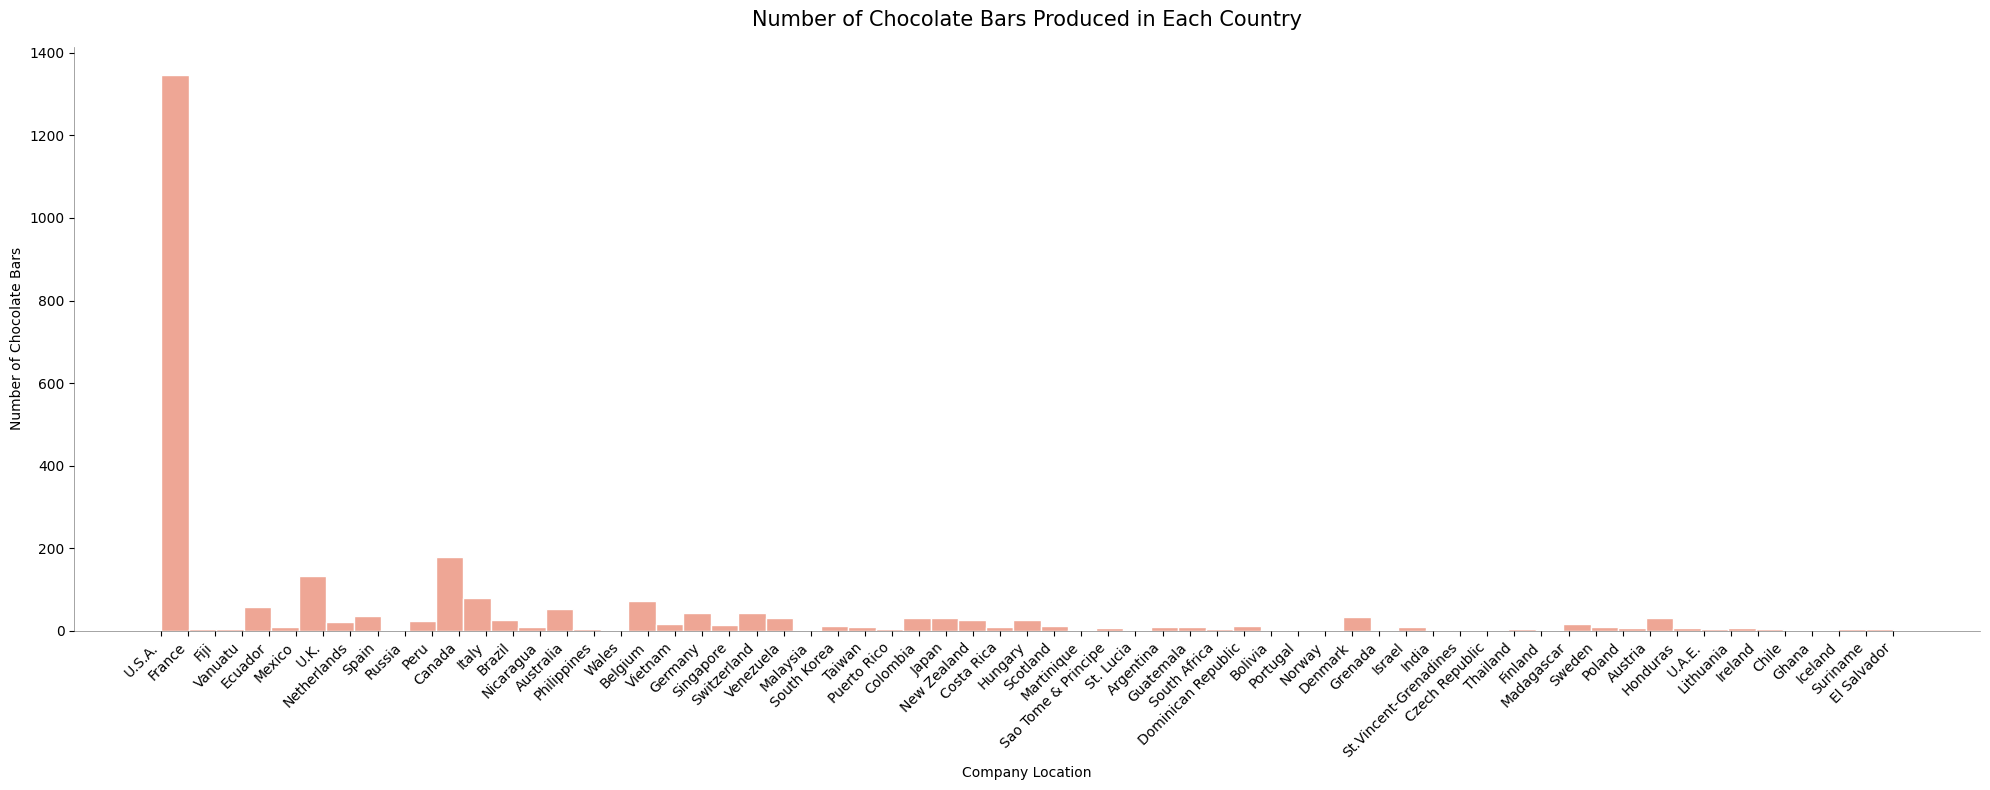

In [110]:
plt.figure(figsize=(20, 8))
plt.hist(
    df['Company Location'],
    bins=63, 
    color='#EEA695',
    edgecolor='white'
)
#need to change the increments to include .25 and .75

plt.xlabel('Company Location')
plt.ylabel('Number of Chocolate Bars')
plt.title('Number of Chocolate Bars Produced in Each Country', fontsize=15, pad=15)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(0.5)
    spine.set_alpha(0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()

Create a chart that shows a comparison (e.g., bar chart, grouped bar, count plot). For this chart, I will explore the country of bean origin and the cocoa percentage.  The x-axis is a categorical variable (something like country of bean origin, manufacturer, company location, etc). The y-axis is some kind of measurement (e.g., cocoa percentage, rating, year). 

Since original dataframe was loaded into this notebook, I'm assuming that the Cocoa Percent column still contains string values. Let's check:


In [62]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2588 entries, 0 to 2587
Data columns (total 10 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   REF                               2588 non-null   int64  
 1   Company (Manufacturer)            2588 non-null   str    
 2   Company Location                  2588 non-null   str    
 3   Review Date                       2588 non-null   int64  
 4   Country of Bean Origin            2588 non-null   str    
 5   Specific Bean Origin or Bar Name  2588 non-null   str    
 6   Cocoa Percent                     2588 non-null   str    
 7   Ingredients                       2501 non-null   str    
 8   Most Memorable Characteristics    2588 non-null   str    
 9   Rating                            2588 non-null   float64
dtypes: float64(1), int64(2), str(7)
memory usage: 202.3 KB


Yes, Cocoa Percent is still a string. I need to change it to a float. 
First, I must remove the % sign.


In [64]:
df['Cocoa Percent'] = df['Cocoa Percent'].str.replace('%', '')
df.head()

,REF,Company (Manufacturer),Company Location,Review Date,Country of Bean Origin,Specific Bean Origin or Bar Name,Cocoa Percent,Ingredients,Most Memorable Characteristics,Rating
0,2454,5150,U.S.A.,2019,Tanzania,"Kokoa Kamili, batch 1",76,"3- B,S,C","rich cocoa, fatty, bready",3.25
1,2454,5150,U.S.A.,2019,Madagascar,"Bejofo Estate, batch 1",76,"3- B,S,C","cocoa, blackberry, full body",3.75
2,2458,5150,U.S.A.,2019,Dominican Republic,"Zorzal, batch 1",76,"3- B,S,C","cocoa, vegetal, savory",3.50
3,2542,5150,U.S.A.,2021,Fiji,"Matasawalevu, batch 1",68,"3- B,S,C","chewy, off, rubbery",3.00
4,2542,5150,U.S.A.,2021,India,"Anamalai, batch 1",68,"3- B,S,C","milk brownie, macadamia,chewy",3.50


Now, I must change Cocoa Percent to a float.

In [89]:
df['Cocoa Percent'] = df['Cocoa Percent'].astype('float')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2588 entries, 0 to 2587
Data columns (total 10 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   REF                               2588 non-null   int64  
 1   Company (Manufacturer)            2588 non-null   str    
 2   Company Location                  2588 non-null   str    
 3   Review Date                       2588 non-null   int64  
 4   Country of Bean Origin            2588 non-null   str    
 5   Specific Bean Origin or Bar Name  2588 non-null   str    
 6   Cocoa Percent                     2588 non-null   float64
 7   Ingredients                       2501 non-null   str    
 8   Most Memorable Characteristics    2588 non-null   str    
 9   Rating                            2588 non-null   float64
dtypes: float64(2), int64(2), str(6)
memory usage: 202.3 KB


Group by country of bean origin (or company location) and calculate the average cocoa percentage using .mean(). I also want to order these values from least to most cocoa percentage using .sort_values()

In [69]:
avg_cocoa_percent = df.groupby('Country of Bean Origin')['Cocoa Percent'].mean().sort_values()
avg_cocoa_percent 

Country of Bean Origin
Martinique    42.000000
Bali          65.000000
Tobago        65.000000
Sulawesi      66.000000
DR Congo      68.000000
                ...    
Ecuador       73.253363
Cuba          74.153846
Gabon         75.000000
Principe      77.000000
Samoa         82.333333
Name: Cocoa Percent, Length: 63, dtype: float64

Create a chart that shows a comparison (e.g., bar chart, grouped bar, count plot)
-I am exploring the relationship between the country of bean origin and the cocoa percentage.
-I chose this type of chart because a bar chart compares quantities (cocoa percentage) across categories (country of bean origin).  
-This chart doesn't really tell me much. Most of the cocoa percentages are in the 70% range. I would think that the percent of cocoa in the chocolate would depend on the quantities of other ingredients added to it (the more sweetener, lecithin, vanilla, etc, the lower the percentage of cocoa (beans and cocoa butter combined)), not on where the bean comes from. A better chart might be seeing how the cocoa percentage influences the rating. But then again, that might have more to do with the taster's preferences. 

Given that most of the values are in the 70% range, I don't think it would vary much by company or company location, either.  

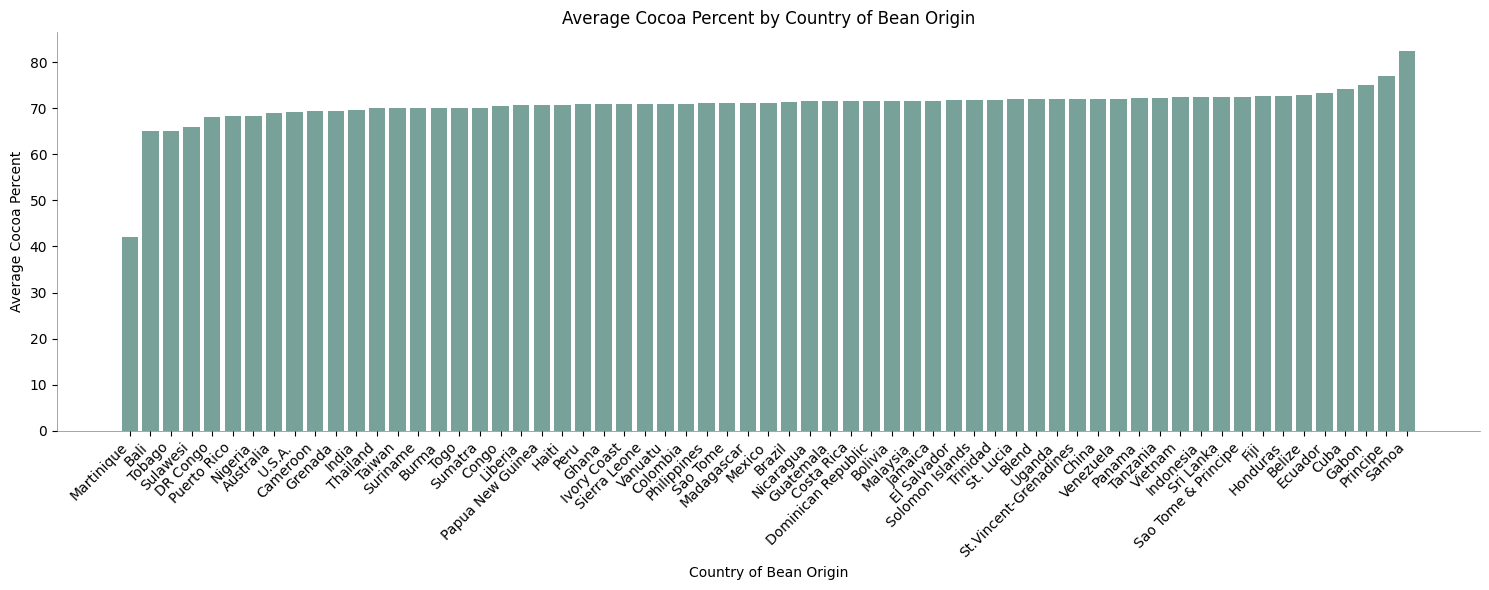

In [111]:
plt.figure(figsize=(15, 6))
plt.bar(avg_cocoa_percent.index, avg_cocoa_percent.values, color='#78A199')

ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(0.5)
    spine.set_alpha(0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.xlabel('Country of Bean Origin')
plt.ylabel('Average Cocoa Percent')
plt.title('Average Cocoa Percent by Country of Bean Origin')
plt.xticks(rotation=45, ha = 'right')
plt.tight_layout()

plt.show()



I tried several groupby() comparisons in the following cells.

In [ ]:
avg_country_origin_rating = df.groupby('Country of Bean Origin')['Rating'].mean().sort_values()
avg_country_origin_rating

Country of Bean Origin
Bali                     2.500000
Puerto Rico              2.714286
Principe                 2.750000
Martinique               2.750000
St.Vincent-Grenadines    2.750000
                           ...   
Congo                    3.318182
Solomon Islands          3.450000
China                    3.500000
Sao Tome & Principe      3.500000
Tobago                   3.625000
Name: Rating, Length: 63, dtype: float64

In [93]:
avg_cocoa_percent_rating = df.groupby('Cocoa Percent')['Rating'].mean().sort_values()
avg_cocoa_percent_rating

Cocoa Percent
53.0     2.000000
91.0     2.166667
100.0    2.285714
89.0     2.625000
99.0     2.625000
42.0     2.750000
46.0     2.750000
57.0     2.750000
60.5     2.750000
72.5     2.750000
84.0     2.812500
55.0     2.859375
81.0     2.916667
61.0     2.964286
90.0     2.972222
62.0     2.984375
85.0     3.000000
83.0     3.000000
60.0     3.005435
76.0     3.021429
82.0     3.041667
71.0     3.068182
80.0     3.086111
77.0     3.098837
73.5     3.125000
58.0     3.125000
71.5     3.125000
75.0     3.161859
65.0     3.163978
64.0     3.195946
73.0     3.197761
74.0     3.213768
72.0     3.216828
88.0     3.218750
56.0     3.250000
79.0     3.250000
87.0     3.250000
86.0     3.250000
70.0     3.265421
68.0     3.290000
67.0     3.335714
66.0     3.348214
78.0     3.386364
69.0     3.461538
63.0     3.500000
50.0     3.750000
Name: Rating, dtype: float64

This didn't do what I wanted it to do. It took each cocoa percentage value (first column) and gave an average of the ratings for each cocoa percent (second column).  It might be useful to graph anyway, to see if there's a relationship between the amount of cocoa in a chocolate bar and the rating it gets.  I think in order to show any relationship, you would have to sort the cocoa percentages from lowest to highest.  It's not letting me do this because it went back to treating the cocoa percent as a string. So, I added back in the code changing it to a float. This didn't work either.
df['Cocoa Percent'] = df['Cocoa Percent'].astype('float')
avg_cocoa_percent_rating = df.groupby('Cocoa Percent'.sort_values())['Rating'].mean()
avg_cocoa_percent_rating


Create a chart that shows a relationship or pattern (e.g., line chart, scatterplot)
I chose a scatterplot
-I am exploring the relationship between cocoa percentage and the chocolate bar rating.
-I chose this type of chart because it compares two numeric variables. 
-This scatterplot helped me notice that most of chocolate bars with 60-80% cocoa had ratings between 2.5 - 4.0. 

In [94]:
avg_rating_cocoa_percent = df.groupby('Rating')['Cocoa Percent'].mean().sort_values(ascending=False)
avg_rating_cocoa_percent

Rating
1.75    90.666667
1.50    84.800000
1.00    78.250000
2.00    76.575758
2.25    73.294118
2.75    72.056047
3.00    71.705993
2.50    71.653846
3.25    71.405063
3.50    71.211473
3.75    71.014706
4.00    70.756522
Name: Cocoa Percent, dtype: float64

In [115]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2588 entries, 0 to 2587
Data columns (total 10 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   REF                               2588 non-null   int64  
 1   Company (Manufacturer)            2588 non-null   str    
 2   Company Location                  2588 non-null   str    
 3   Review Date                       2588 non-null   int64  
 4   Country of Bean Origin            2588 non-null   str    
 5   Specific Bean Origin or Bar Name  2588 non-null   str    
 6   Cocoa Percent                     2588 non-null   float64
 7   Ingredients                       2501 non-null   str    
 8   Most Memorable Characteristics    2588 non-null   str    
 9   Rating                            2588 non-null   float64
dtypes: float64(2), int64(2), str(6)
memory usage: 202.3 KB


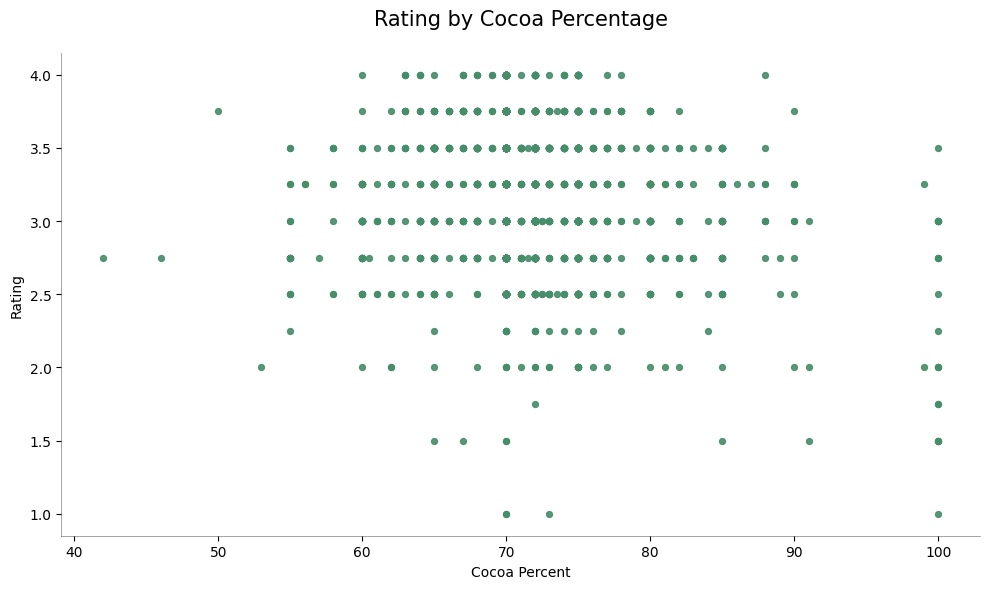

In [130]:
plt.figure(figsize=(10, 6))
plt.scatter(df['Cocoa Percent'], 
            df['Rating'], 
            color = "#468D6A", 
            alpha = 0.9,
            s = 18)

ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(0.5)
    spine.set_alpha(0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.xlabel('Cocoa Percent')
plt.ylabel('Rating')
plt.title('Rating by Cocoa Percentage', fontsize=15, pad=20)

plt.tight_layout()

plt.show()